<a href="https://colab.research.google.com/github/Siva1212-genious/ML-Algorithms---ScikitLearn/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

In [3]:
from urllib.request import urlretrieve

urlretrieve(medical_charges_url, "medical.cv")

('medical.cv', <http.client.HTTPMessage at 0x7ee73fc7bb10>)

In [4]:
medical_data = pd.read_csv("medical.cv")

medical_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [5]:
smoker_data = medical_data[medical_data['smoker'] == 'yes']

non_smoker_data = medical_data[medical_data['smoker'] == 'no']

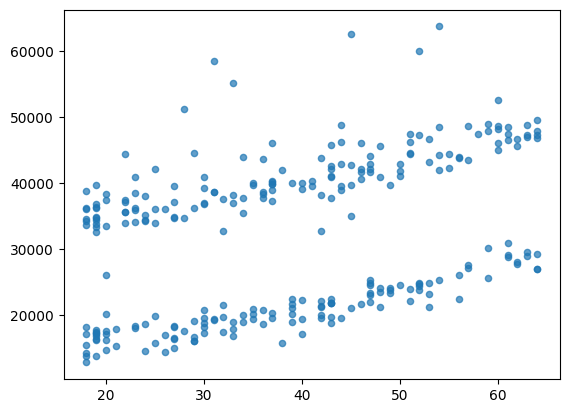

In [6]:
plt.scatter(smoker_data['age'], smoker_data['charges'], alpha =0.7, s =20)

plt.show()

In [7]:
def model_example(ages, w, b):
  return w * ages + b

In [8]:
def root_mean_square_error(predictions, targets):
  return np.sqrt(np.mean(np.square(predictions-targets)))

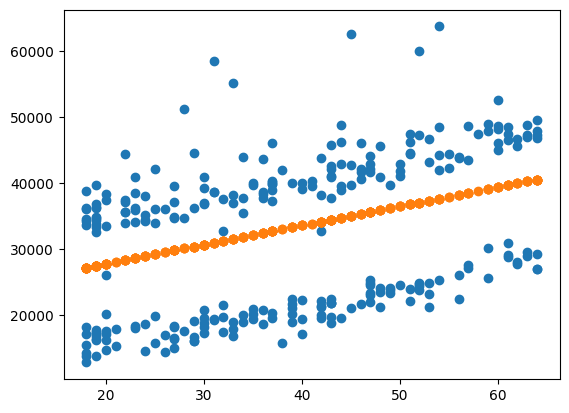

np.float64(10771.378904781232)

In [9]:
ages = smoker_data['age']
w = 290
b = 22000

values = model_example(ages, w, b)

plt.scatter(ages, smoker_data['charges'])
plt.scatter(ages, values)

plt.show()

root_mean_square_error(values, smoker_data['charges'])

Rmse:  10711.00334810241


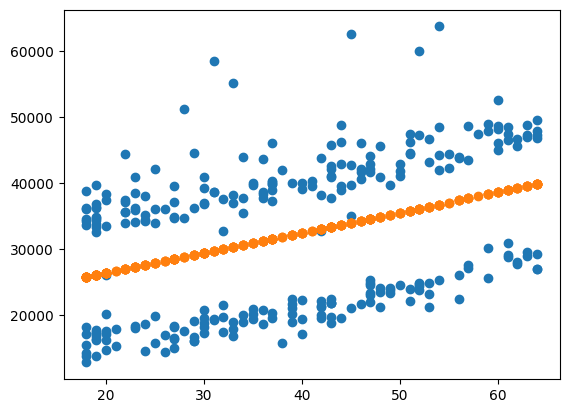

In [10]:
from sklearn.linear_model import LinearRegression

#Ordinary Least Squares Method

inputs = smoker_data[['age']]
targets = smoker_data['charges']


model = LinearRegression()

model.fit(inputs, targets)

predictions = model.predict(inputs)

loss = root_mean_square_error(predictions, targets)
print("Rmse: ", loss)

plt.scatter(inputs, targets)
plt.scatter(inputs, predictions)
plt.show()



RMSE:  4662.505766636395
w:  [267.24891283]
b:  -2091.4205565650864
[2719.0598744  5391.54900271 6727.79356686 ... 2719.0598744  2719.0598744
 3520.80661289]


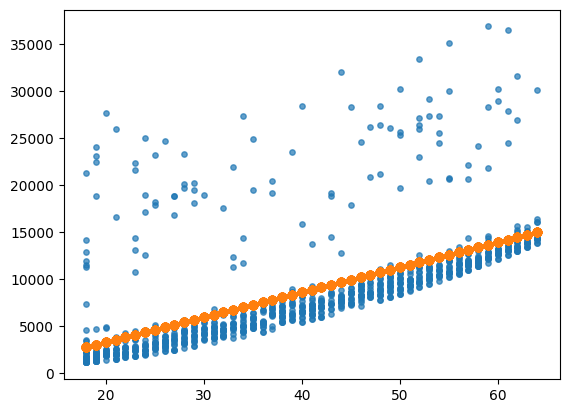

In [11]:
from sklearn.linear_model import LinearRegression

#Ordinary Least Squares Method

inputs = non_smoker_data[['age']]
targets = non_smoker_data['charges']

model = LinearRegression()

model.fit(inputs, targets)

prediction = model.predict(inputs)
#prediction= model.predict(np.array([[18],[34],[56],[78],[23],[18],[22],[32],[45]]))

loss = root_mean_square_error(prediction, targets)
print("RMSE: ", loss)
print("w: ", model.coef_)
print("b: ", model.intercept_)
print(prediction)

plt.scatter(inputs, targets, alpha = 0.7, s=15)
plt.scatter(inputs, prediction)

plt.show()

In [ ]:
!pip install scikit-learn

Rmse:  4662.583212005062


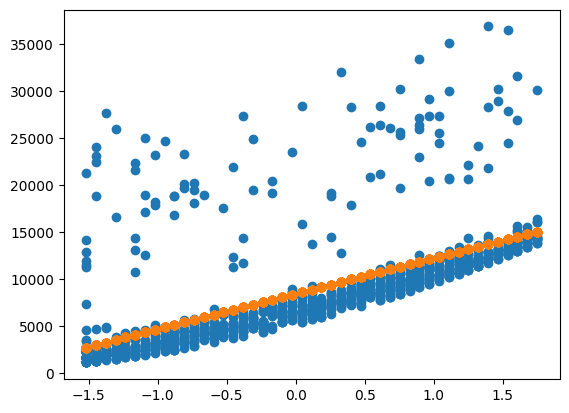

In [12]:
#Now Let us use Stochastic Gradient Descendent Method.

#Here i am using same data to train and test.

import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

inputs = non_smoker_data[['age']]
targets = non_smoker_data['charges']

Scaler = StandardScaler()

inputs = Scaler.fit_transform(inputs)

model = SGDRegressor(max_iter = 1000, learning_rate="invscaling")

model.fit(inputs, targets)

prediction = model.predict(inputs)

loss = np.sqrt(np.mean(np.square(targets-prediction)))
print("Rmse: ", loss)

plt.scatter(inputs, targets)
plt.scatter(inputs, prediction)

plt.show()

RMSE:   4428.074827506876
w:  [3708.87015324]
b:  [8494.04346909]


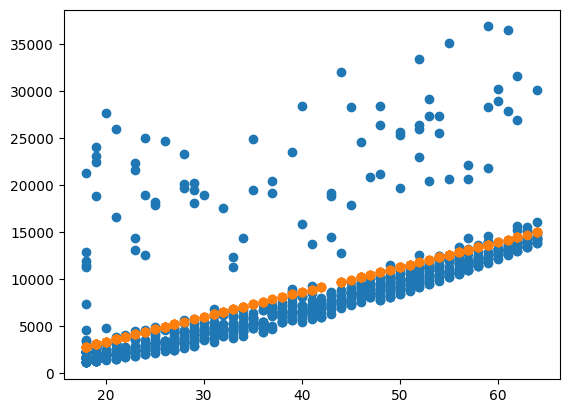

In [13]:
#We will perform SGD Regression process
# Here, i will split the training and testing data seperately(80% train, 20% test) from the same dataset


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split

x = non_smoker_data[['age']]
y = non_smoker_data['charges']

#Splitting Data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


#Scalling Data

Scaler = StandardScaler()

x_scalar_train = Scaler.fit_transform(x_train)
x_scalar_test = Scaler.transform(x_test)

#Now Applying the model

model = SGDRegressor(max_iter = 1500, learning_rate='invscaling', random_state = 42)

model.fit(x_scalar_train, y_train)

prediction = model.predict(x_scalar_test)

loss = np.sqrt(np.mean(np.square(y_test-prediction)))
print("RMSE:  ", loss)
print("w: ", model.coef_)
print("b: ", model.intercept_)

plt.scatter(x_train,y_train)
plt.scatter(x_test, prediction)

plt.show()



In [14]:
#Now, i will include all the weights in Ordinary Least Squares method

#For that i need to convert the string(non-integer values and classify the other weights)

# In our dataset, we need to classify smoker and region

#Classifying Smoker
smoker_codes = {"yes": 1, "no": 0}
medical_data['smoker_codes'] = medical_data.smoker.map(smoker_codes)



#Classifying Region
#We need to use "onehotencoder" to encode the region of 4 values.

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False)
region_encoder = encoder.fit_transform(medical_data[['region']]).astype(int)

#Now i am appending or concatinating this to my medical_data csv file

medical_data[['northeast', 'northwest', 'southeast', 'southwest']] = region_encoder



#Now Let's change for sex too

sex_codes = {'female': 0, 'male':1}
medical_data['sex_codes'] = medical_data.sex.map(sex_codes)

medical_data

,age,sex,bmi,children,smoker,region,charges,smoker_codes,northeast,northwest,southeast,southwest,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0,0,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,0,0,1,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,0,0,1,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,0,1,0,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0,1,0,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,0,0,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0,1,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0,0,1,0


RMSE:  4573.074988795492
W:  [ 264.48143811 -525.97048681   18.98046182  587.45825749  733.68301887
  185.554256   -258.36537156 -660.87190331]
b:  -2940.7471545563003


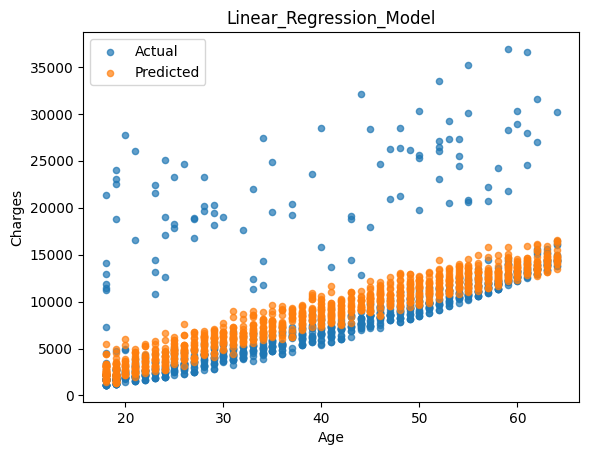

In [15]:
#Now Lets add all the weights and lets implement the LinearRegression model for non_smoker_model


from sklearn.linear_model import LinearRegression

# Filter non-smoker data using the numerical 'smoker_codes' column
non_smoker_data = medical_data[medical_data['smoker_codes'] == 0]

# Correctly select multiple columns as input features by passing a single list of column names
inputs = non_smoker_data[['age', 'sex_codes', 'bmi', 'children', 'northeast', 'northwest','southeast','southwest']]
targets = non_smoker_data['charges']

model = LinearRegression()

model.fit(inputs, targets)

predictions = model.predict(inputs)

loss = root_mean_square_error(predictions, targets)
print("RMSE: ", loss)
print("W: ", model.coef_)
print("b: ", model.intercept_)

# Plotting with 'age' as the x-axis for better visualization
plt.scatter(non_smoker_data['age'], targets, label='Actual', alpha=0.7, s =20)
plt.scatter(non_smoker_data['age'], predictions, label='Predicted', alpha = 0.7, s = 20)

plt.legend()
plt.xlabel("Age") # Changed label to 'Age' since we are plotting age
plt.ylabel("Charges")
plt.title("Linear_Regression_Model")

plt.show()

RMSE:  6697.870400250913
w:  [  248.7846979   1492.98342536  -441.47902506   221.73137219
   843.72195136   454.86841084 -1140.58590679  -158.0044554 ]
b:  -23448.50204106056


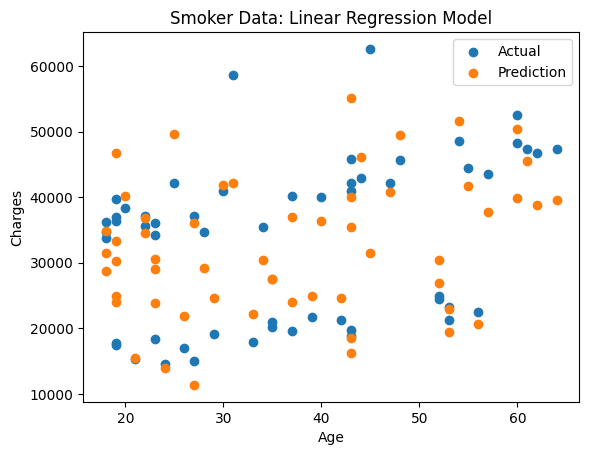

In [16]:
#Now lets do for the smoker_data

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


smoker_data = medical_data[medical_data['smoker_codes'] == 1]

inputs = smoker_data[['age', 'bmi', 'sex_codes', 'children', 'northeast', 'northwest','southeast', 'southwest', ]]
targets = smoker_data['charges']

#splitting the data

x_train, x_test, y_train, y_test = train_test_split(inputs, targets ,test_size = 0.2, random_state=42)

model = LinearRegression()

model.fit(x_train, y_train)

prediction = model.predict(x_test)

loss = root_mean_square_error(prediction, y_test)
print("RMSE: ", loss)
print("w: ", model.coef_)
print("b: ", model.intercept_)

# Plotting 'age' from x_test against y_test and prediction
plt.scatter(x_test['age'], y_test, label='Actual')
plt.scatter(x_test['age'], prediction, label='Predicted')
plt.legend(['Actual', 'Prediction'])
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Smoker Data: Linear Regression Model')

plt.show()